In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


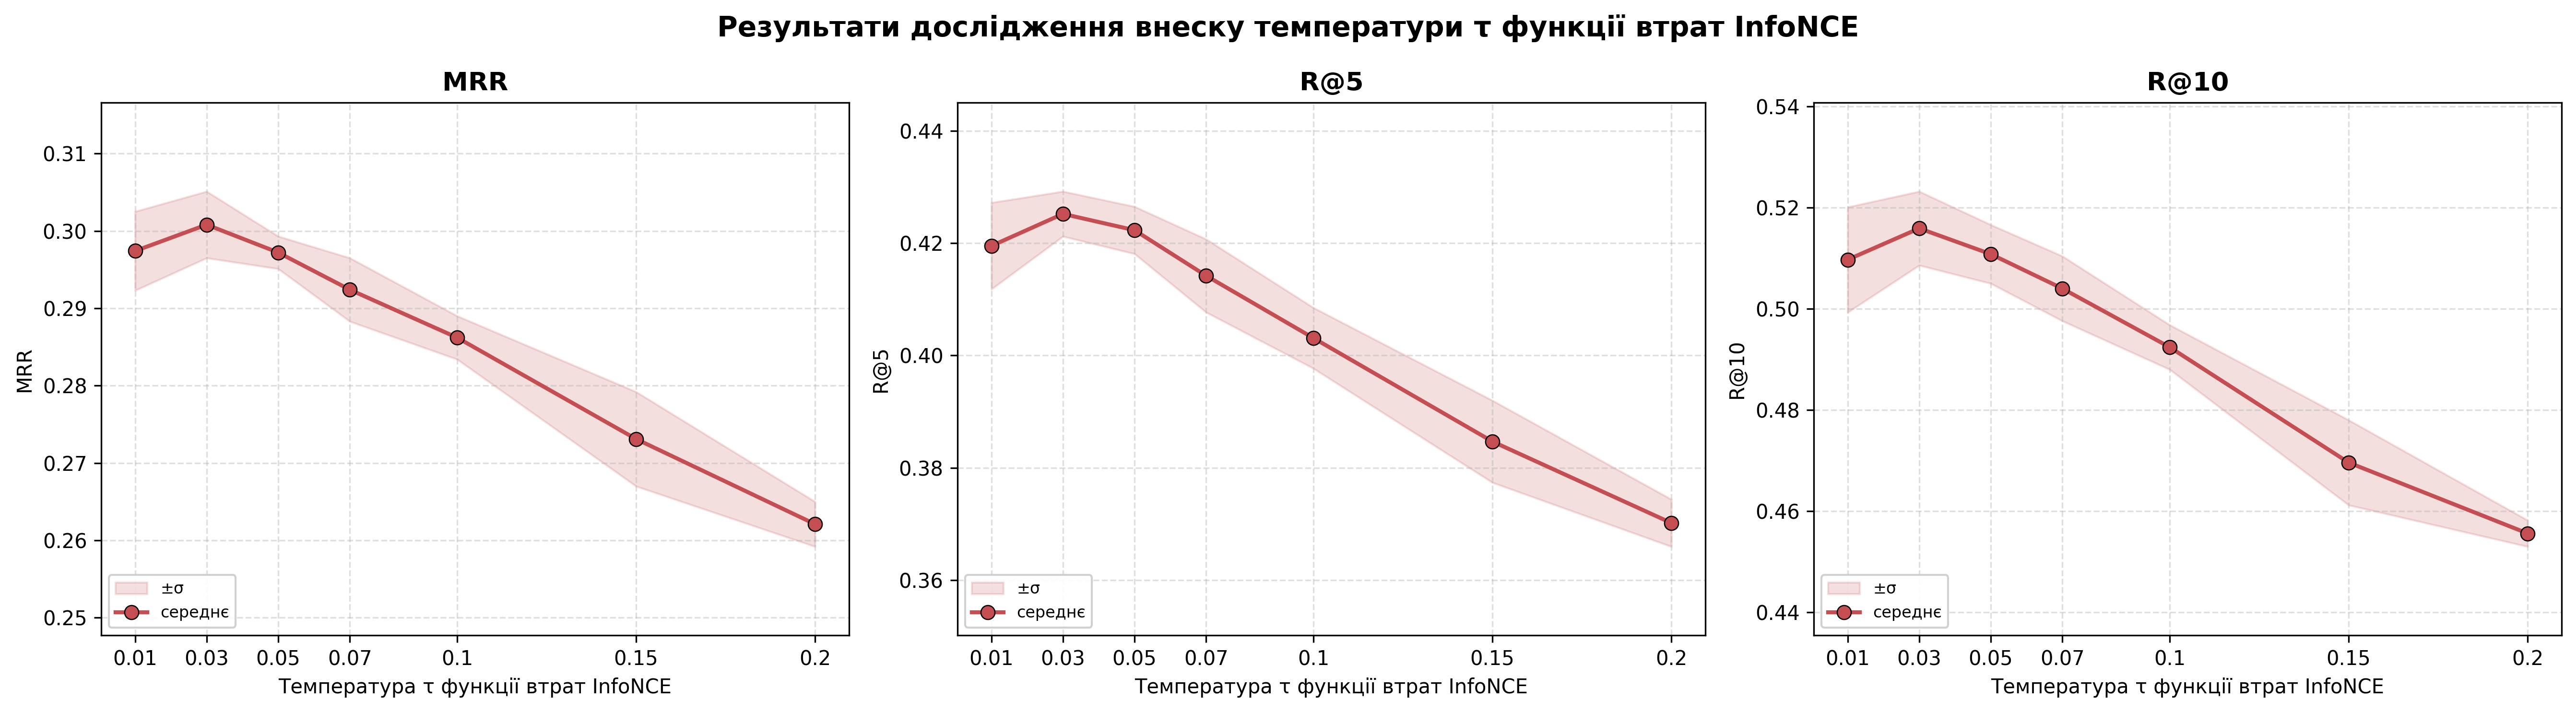

In [2]:
import matplotlib.pyplot as plt
import numpy as np

taus = np.array([0.01, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20])

mrr      = np.array([0.2974, 0.3008, 0.2972, 0.2924, 0.2862, 0.2731, 0.2621])
mrr_std  = np.array([0.0051, 0.0043, 0.0021, 0.0041, 0.0028, 0.0061, 0.0029])

r5       = np.array([0.4195, 0.4252, 0.4223, 0.4142, 0.4031, 0.3847, 0.3702])
r5_std   = np.array([0.0077, 0.0040, 0.0042, 0.0065, 0.0054, 0.0073, 0.0042])

r10      = np.array([0.5097, 0.5159, 0.5108, 0.5040, 0.4924, 0.4696, 0.4556])
r10_std  = np.array([0.0104, 0.0073, 0.0058, 0.0064, 0.0044, 0.0084, 0.0026])

metrics = [
    ('MRR',  mrr, mrr_std),
    ('R@5',  r5,  r5_std),
    ('R@10', r10, r10_std),
]

chosen_tau = 0.05
line_color = '#C44E52'
band_color = '#C44E52'
ref_color  = '#4C72B0'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, dpi=300)

for ax, (name, vals, errs) in zip(axes, metrics):
    ax.fill_between(taus, vals - errs, vals + errs,
                    color=band_color, alpha=0.18, label='±σ')
    ax.plot(taus, vals, marker='o', color=line_color,
            linewidth=2, markersize=7, markeredgecolor='black',
            markeredgewidth=0.6, label='середнє')

    idx_full = int(np.where(taus == chosen_tau)[0][0])
    full_val = vals[idx_full]

    ax.set_xticks(taus)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.minorticks_off()

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Температура τ функції втрат InfoNCE')
    ax.set_ylabel(name)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

    lo = float((vals - errs).min())
    hi = float((vals + errs).max())
    pad = (hi - lo) * 0.25
    ax.set_ylim(lo - pad, hi + pad)

    ax.legend(loc='lower left', fontsize=8, framealpha=0.9)

fig.suptitle('Результати дослідження внеску температури τ функції втрат InfoNCE',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()